In [1]:
# plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# calculating/regridding
import xarray as xr                        
import numpy as np 
import pandas as pd
import xesmf as xe
from scipy.stats import linregress

In [2]:
omi_mls_ds = xr.open_dataarray("/glade/u/home/mvoncyga/SOARS_2025/300hpa_full_monthly_omimls_tco.nc")
omi_mls_ds = omi_mls_ds.rename({'latitude': 'lat', 'longitude': 'lon'})

# shifting lon to be 0-360
omi_mls_ds['lon'] = omi_mls_ds['lon'] % 360
omi_mls_ds = omi_mls_ds.sortby('lon')

In [3]:
omi_mls_ds = omi_mls_ds.sel(lat=slice(0.5,75.5))

In [4]:
cesm_output = xr.open_dataarray("/glade/u/home/mvoncyga/SOARS_2025/300hPa_tco_cesm_monthly.nc")

In [5]:
regridder = xe.Regridder(cesm_output, omi_mls_ds, 'bilinear', periodic=True) 
cesm_regridded = regridder(cesm_output)

In [6]:
global_cesm_data = cesm_regridded.mean(dim={'lat','lon'})
#global_cesm_data

In [7]:
# update model dates to 1 month offset
offset = pd.date_range(start='2005-01-01', periods=240, freq='MS')

# assign the new date coordinate
cesm_regridded = cesm_regridded.assign_coords(time=offset)

In [8]:
cesm_dates = global_cesm_data.coords['time']
num_cesm_dates = np.arange(0, len(cesm_dates), 1)

In [9]:
cesm_slope, cesm_intercept, r_value_cesm, p_value, std_err_cesm = linregress(num_cesm_dates, global_cesm_data)
cesm_lin_reg = cesm_slope * num_cesm_dates + cesm_intercept
r_squared_cesm = r_value_cesm**2

In [10]:
std_err_cesm

0.0020268386181738003

In [11]:
cesm_regridded

<xarray.DataArray (time: 240, lat: 76, lon: 360)> Size: 26MB
array([[[20.581808, 20.712498, 20.710047, ..., 20.140991, 20.226364,
         20.395645],
        [21.737356, 21.844748, 21.856451, ..., 21.275763, 21.42355 ,
         21.584824],
        [22.740717, 22.90233 , 23.049555, ..., 22.468567, 22.534702,
         22.615   ],
        ...,
        [27.673018, 27.696272, 27.707855, ..., 27.577633, 27.614414,
         27.645113],
        [27.265171, 27.259064, 27.24337 , ..., 27.234692, 27.249788,
         27.2614  ],
        [26.687859, 26.652473, 26.617895, ..., 26.768166, 26.746035,
         26.71961 ]],

       [[17.02306 , 16.967995, 16.906378, ..., 17.588066, 17.329405,
         17.135595],
        [17.515144, 17.473104, 17.407955, ..., 17.980875, 17.770388,
         17.606493],
        [18.115934, 18.059437, 18.004072, ..., 18.438143, 18.282265,
         18.18394 ],
...
        [29.921583, 29.877052, 29.839682, ..., 30.091255, 30.031073,
         29.973434],
        [29.922829, 29.918245, 29.911419, ..., 29.922785, 29.925146,
         29.925144],
        [29.904501, 29.93622 , 29.963247, ..., 29.816416, 29.842482,
         29.872316]],

       [[19.362787, 19.153364, 18.95211 , ..., 19.764647, 19.665545,
         19.537624],
        [20.31928 , 20.119886, 19.913425, ..., 20.618729, 20.550316,
         20.463966],
        [21.437418, 21.309898, 21.129337, ..., 21.546701, 21.549068,
         21.515265],
        ...,
        [28.783934, 28.800285, 28.83246 , ..., 28.827576, 28.799337,
         28.783949],
        [29.021044, 29.044674, 29.06992 , ..., 28.965645, 28.983912,
         29.00109 ],
        [29.265614, 29.211628, 29.168827, ..., 29.249107, 29.288515,
         29.296022]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 608B 0.5 1.5 2.5 3.5 4.5 ... 71.5 72.5 73.5 74.5 75.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 2kB 2005-01-01 2005-02-01 ... 2024-12-01
Attributes:
    regrid_method:  bilinear

In [12]:
def timeseries_plot(dates, dataset, linreg, title, r_squared, slope, intercept, save=False, save_level='999'):
    plt.figure(figsize=(10,6))
    ax = plt.axes()

    plt.plot(dates, dataset, linewidth=2, color='#5acc0e')
    plt.plot(dates, linreg, color='black', linestyle='dashdot', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.7)
    mean = f"{dataset.mean().data:.3f}"

    ax.text(0.075, 0.07, '$R^2=$' + f"{r_squared:.3f}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15)
    ax.text(0.22, 0.02, "Trend: " f'y = {slope:.2f}x + {intercept:.2f}' + " DU/month", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15)
    ax.text(0.1055, 0.125, 'Mean: ' + str(mean) + " DU", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15)


    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which='major', width=2)
    ax.tick_params(which='minor', width=1)
    ax.tick_params(which='major', length=5)
    ax.tick_params(which='minor', length=4)

    plt.title(title, fontsize=19)
    plt.ylabel("$\mathregular{O_3}$ Concentration (DU)", fontsize=15)
    plt.xticks(rotation=45)
    plt.tight_layout()

    
    if save==True:
       plt.savefig("figures/Annual_Time_Series_" + save_level + "_hPa.png")
        
    plt.show()

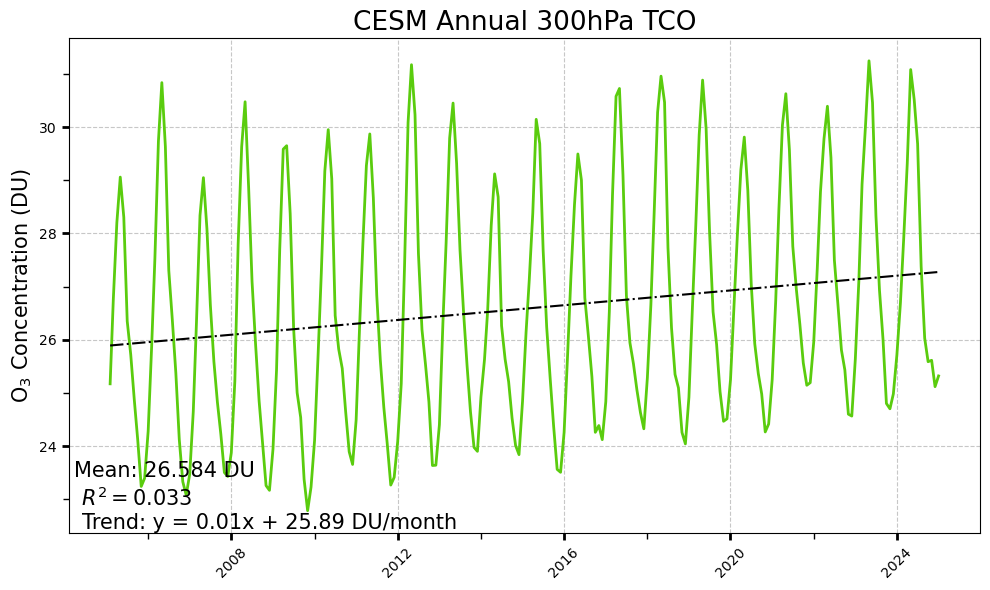

In [13]:
timeseries_plot(cesm_dates, global_cesm_data, cesm_lin_reg, "CESM Annual 300hPa TCO", r_squared_cesm, cesm_slope, cesm_intercept)

In [14]:
global_omi_mls_data = omi_mls_ds.mean(dim={'lat','lon'})
#global_omi_mls_data

In [15]:
omi_mls_dates = omi_mls_ds.coords['yearmonth']
num_omi_mls_dates = np.arange(0, len(omi_mls_dates), 1)

In [16]:
omi_mls_slope, omi_mls_intercept, r_value_omi_mls, p_value, std_err_omi_mls = linregress(num_omi_mls_dates, global_omi_mls_data)
omi_mls_lin_reg = omi_mls_slope * num_omi_mls_dates + omi_mls_intercept
r_squared_omi_mls = r_value_omi_mls**2

In [17]:
global_omi_mls_data.size

240

In [18]:
std_err_omi_mls

0.0016362576225986607

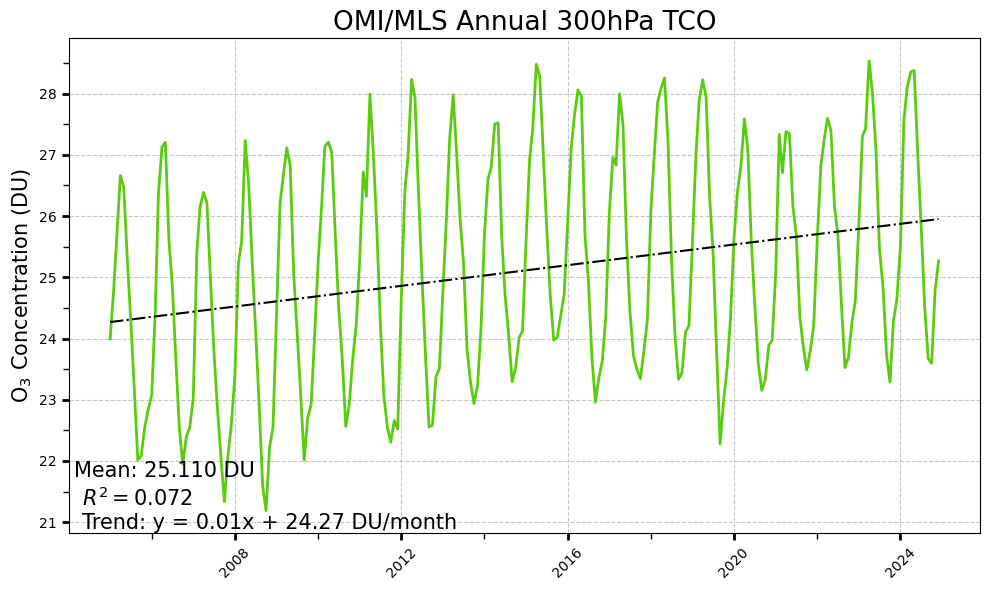

In [19]:
timeseries_plot(omi_mls_dates, global_omi_mls_data, omi_mls_lin_reg, "OMI/MLS Annual 300hPa TCO", r_squared_omi_mls, omi_mls_slope, omi_mls_intercept) # True, "OMIMLS_300"

In [20]:
global_omi_mls_data = global_omi_mls_data.rename({"yearmonth": "time"})
difference = global_cesm_data - global_omi_mls_data

In [21]:
diff_dates = difference.coords['time']
num_diff_dates = np.arange(0, len(diff_dates), 1)

In [22]:
diff_slope, diff_intercept, r_value_diff, p_value, std_err_diff = linregress(num_diff_dates, difference)
diff_lin_reg = diff_slope * num_diff_dates + diff_intercept
r_squared_diff = r_value_diff**2

In [23]:
std_err_diff

0.001274492580836247

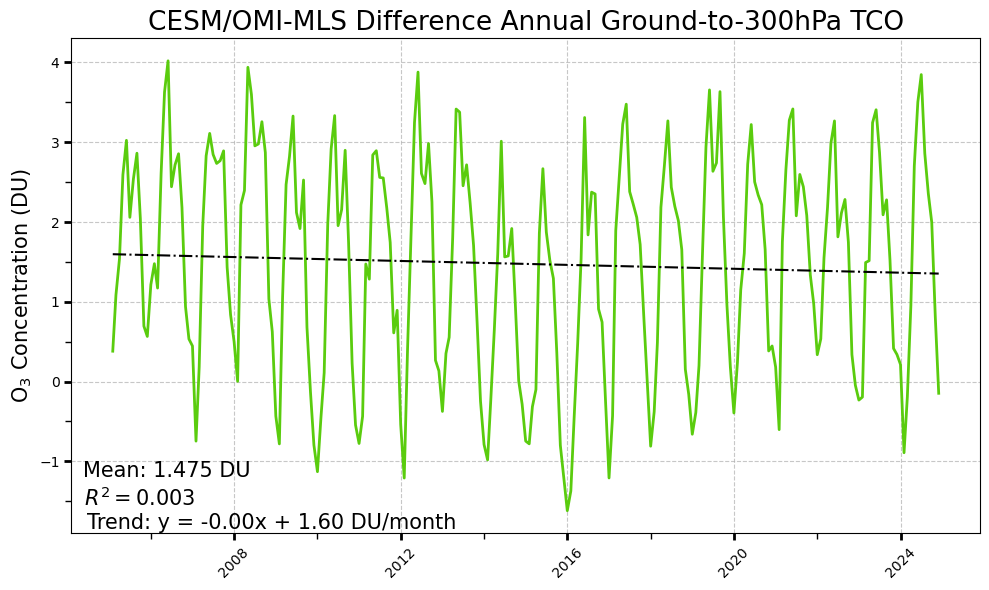

In [24]:
timeseries_plot(diff_dates, difference, diff_lin_reg, "CESM/OMI-MLS Difference Annual Ground-to-300hPa TCO", r_squared_diff, diff_slope, diff_intercept) #True, "OMIMLS_100"

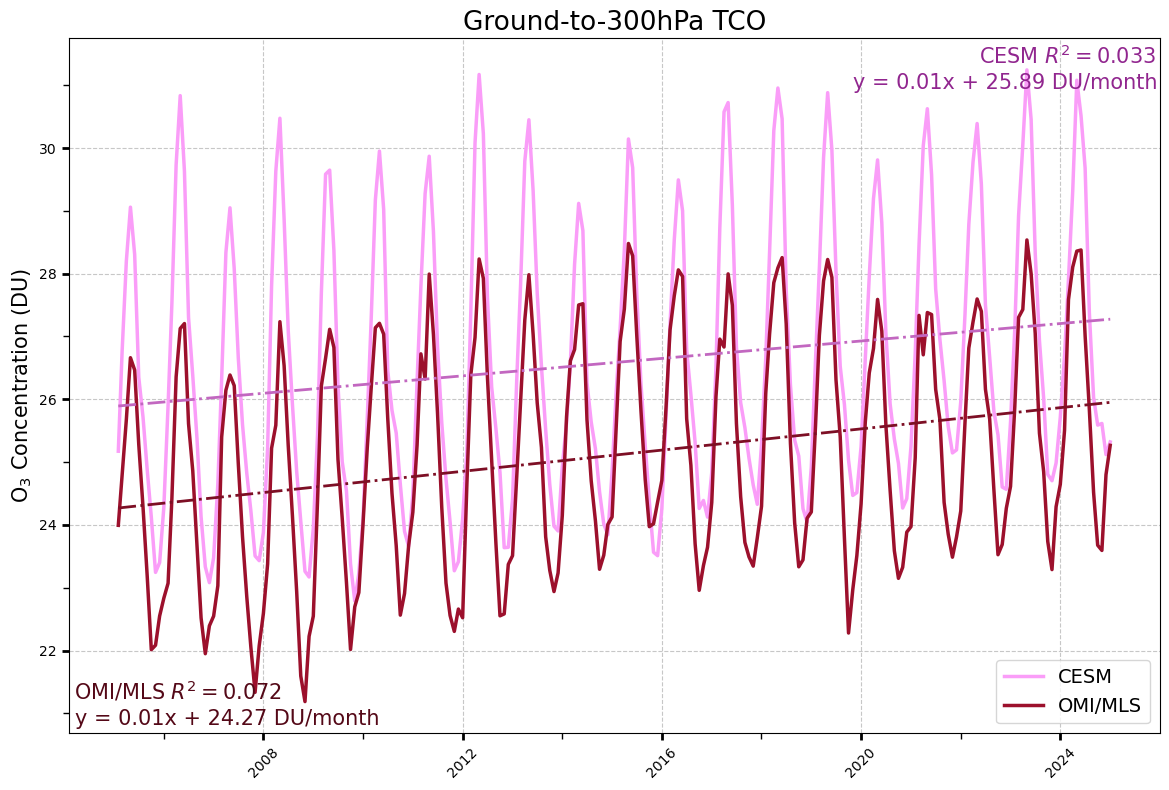

In [25]:
plt.figure(figsize=(12,8), linewidth=50)
ax = plt.axes()

plt.plot(cesm_dates, global_cesm_data, linewidth=2.5, color='#fa9df8')
plt.plot(cesm_dates, global_omi_mls_data, linewidth=2.5, color="#9c102c")

plt.plot(cesm_dates, cesm_lin_reg, color='#c267c0', linestyle='dashdot', linewidth=2)
plt.plot(cesm_dates, omi_mls_lin_reg, color='#7d0f25', linestyle='dashdot', linewidth=2)
#plt.plot(cesm_dates, linreg, color='black', linestyle='dashdot', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.7)

#cesm_mean = f"{cesm_dates.mean().data:.3f}"

ax.text(0.915, 0.975, 'CESM ' + '$R^2=$' + f"{r_squared_cesm:.3f}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15, color='#91268f')
ax.text(0.858, 0.935, f'y = {cesm_slope:.2f}x + {cesm_intercept:.2f}' + " DU/month", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15, color='#91268f')


#omi_mls_mean = f"{cesm_dates.mean().data:.3f}"

ax.text(0.1, 0.06, 'OMI/MLS ' + '$R^2=$' + f"{r_squared_omi_mls:.3f}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15, color='#540817')
ax.text(0.145, 0.02, f'y = {omi_mls_slope:.2f}x + {omi_mls_intercept:.2f}' + " DU/month", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=15, color='#540817')


ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='major', width=2)
ax.tick_params(which='minor', width=1)
ax.tick_params(which='major', length=5)
ax.tick_params(which='minor', length=4)


plt.legend(['CESM', 'OMI/MLS'], loc='lower right', prop={'size':  14})
           
plt.title("Ground-to-300hPa TCO", fontsize=19)
plt.ylabel("$\mathregular{O_3}$ Concentration (DU)", fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
    
plt.savefig("figures/Annual_Time_Series_300_hPa_BOTH.png")

plt.show()